# Scary Stochastics, Week 2: Poisson Processes
## Notebook 1 of 3 — Per-House Arrivals & Candy Marks

Twenty-five houses on a street, each handing out candy. Trick-or-treater arrivals at each house follow a **non-homogeneous Poisson process** — the rate isn't constant all evening, it ramps up toward a dusk peak and tapers off. Each arrival is also **marked** with the candy type that house hands out, which is what gives us the candy breakdown below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Trick-or-treat palette (extends the harvest palette with candy red + goblin green)
PALETTE = {
    "red":    "#C8102E",  # candy red
    "orange": "#E8741C",  # pumpkin orange
    "rust":   "#B5451B",  # burnt orange/rust
    "purple": "#3B2145",  # deep purple
    "mustard":"#D9A404",  # mustard gold
    "green":  "#3F7A3F",  # goblin green
    "black":  "#1B1B1B",
    "cream":  "#FBF3E1",
}

CANDY_TYPES = ["Full-size", "Fun-size", "Pretzels", "Chips", "Fruit"]
CANDY_COLORS = [PALETTE["red"], PALETTE["orange"], PALETTE["mustard"], PALETTE["purple"], PALETTE["green"]]

N_HOUSES = 25
EVENING_START, EVENING_END = 0, 180  # minutes since 6:00 PM (evening runs 6:00-9:00 PM)

def minute_to_clock(m):
    """Convert minutes-since-6:00-PM into a clock label, e.g. 90 -> '7:30 PM'."""
    total = 18 * 60 + int(m)
    hh, mm = (total // 60) % 24, total % 60
    period = "AM" if hh < 12 else "PM"
    hh12 = hh % 12
    hh12 = 12 if hh12 == 0 else hh12
    return f"{hh12}:{mm:02d} {period}"

plt.rcParams.update({
    "figure.facecolor": PALETTE["cream"],
    "axes.facecolor": PALETTE["cream"],
    "axes.edgecolor": PALETTE["black"],
    "text.color": PALETTE["black"],
    "axes.labelcolor": PALETTE["black"],
    "xtick.color": PALETTE["black"],
    "ytick.color": PALETTE["black"],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

### Build the street: 25 houses

In [2]:
# 25 houses on the street, each with a popularity level, a candy archetype,
# and a service rate (how many treaters per minute they can greet)
house_ids = np.arange(1, N_HOUSES + 1)

popularity = np.random.uniform(0.5, 2.5, N_HOUSES)
archetype = np.random.choice(CANDY_TYPES, size=N_HOUSES, p=[0.15, 0.35, 0.2, 0.15, 0.15])

# Generous houses (full-size bars) take longer per treater than a quick fruit hand-out
BASE_SERVICE = {"Full-size": 0.4, "Fun-size": 3.0, "Pretzels": 2.3, "Chips": 2.6, "Fruit": 4.0}
service_rate = np.array([BASE_SERVICE[a] * np.random.uniform(0.85, 1.15) for a in archetype])

houses_df = pd.DataFrame({
    "House": house_ids,
    "Popularity": popularity.round(2),
    "Archetype": archetype,
    "ServiceRate_per_min": service_rate.round(2),
})
houses_df.head()

,House,Popularity,Archetype,ServiceRate_per_min
0,1,1.25,Chips,2.97
1,2,2.40,Fun-size,3.25
2,3,1.96,Pretzels,2.60
3,4,1.70,Pretzels,2.57
4,5,0.81,Full-size,0.41


### Simulate arrivals (thinning algorithm) + candy marks

We simulate each house's arrivals with the classic **thinning** method for non-homogeneous Poisson processes: propose candidate arrival times from the *fastest* possible rate, then randomly keep ('thin') each one with probability equal to the actual rate at that moment divided by the fastest rate.

In [3]:
def base_rate(t):
    """Street-wide base arrival rate (treaters/min) before house popularity scaling.
    Non-homogeneous: rises toward a dusk peak, then tapers off."""
    peak_t, width, peak_rate = 90, 40, 0.18
    return peak_rate * np.exp(-0.5 * ((t - peak_t) / width) ** 2)

def simulate_nhpp(popularity_i, t_start=EVENING_START, t_end=EVENING_END):
    """Simulate one house's arrivals via thinning (non-homogeneous Poisson process)."""
    lam_max = popularity_i * 0.18  # 0.18 is base_rate's peak value
    t, arrivals = t_start, []
    while t < t_end:
        t += np.random.exponential(1 / lam_max)
        if t < t_end and np.random.uniform() < (popularity_i * base_rate(t)) / lam_max:
            arrivals.append(t)
    return np.array(arrivals)

def candy_probs_for(archetype_label):
    """A house mostly hands out its archetype candy, with a little variety mixed in."""
    probs = np.full(len(CANDY_TYPES), 0.075)
    probs[CANDY_TYPES.index(archetype_label)] = 0.7
    return probs / probs.sum()

records = []
for _, row in houses_df.iterrows():
    arrivals = simulate_nhpp(row["Popularity"])
    probs = candy_probs_for(row["Archetype"])
    candies = np.random.choice(CANDY_TYPES, size=len(arrivals), p=probs)
    for t, c in zip(arrivals, candies):
        records.append((row["House"], t, c))

arrivals_df = pd.DataFrame(records, columns=["House", "ArrivalMin", "CandyType"])
arrivals_df.head()

,House,ArrivalMin,CandyType
0,1,20.422139,Chips
1,1,35.140551,Chips
2,1,35.647962,Chips
3,1,40.144538,Chips
4,1,44.576431,Chips


### Visual 1 — One house's arrival timeline

Taking the street's most popular house as an example: its arrival rate curve (red) against its actual simulated arrivals (the tick marks).

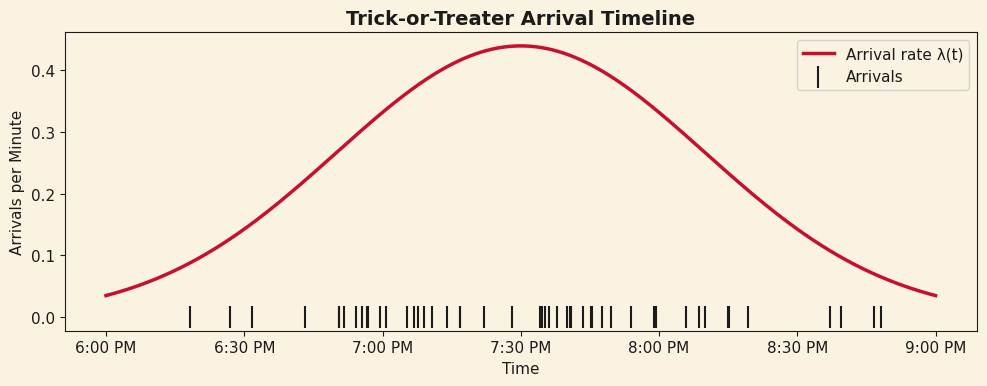

In [4]:
busiest = houses_df.loc[houses_df["Popularity"].idxmax()]
h_arrivals = arrivals_df.loc[arrivals_df["House"] == busiest["House"], "ArrivalMin"].values

t_grid = np.linspace(EVENING_START, EVENING_END, 300)
rate_curve = busiest["Popularity"] * base_rate(t_grid)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_grid, rate_curve, color=PALETTE["red"], linewidth=2.5, label="Arrival rate λ(t)")
ax.scatter(h_arrivals, np.zeros_like(h_arrivals), color=PALETTE["black"],
           marker="|", s=250, label="Arrivals")
tick_mins = np.arange(0, 181, 30)
ax.set_xticks(tick_mins)
ax.set_xticklabels([minute_to_clock(m) for m in tick_mins])
ax.set_xlabel("Time")
ax.set_ylabel("Arrivals per Minute")
ax.set_title("Trick-or-Treater Arrival Timeline")
ax.legend()
plt.tight_layout()
plt.savefig("01_arrival_timeline.png", dpi=150, facecolor=PALETTE["cream"])
plt.show()

### Visual 2 — What's each house handing out?

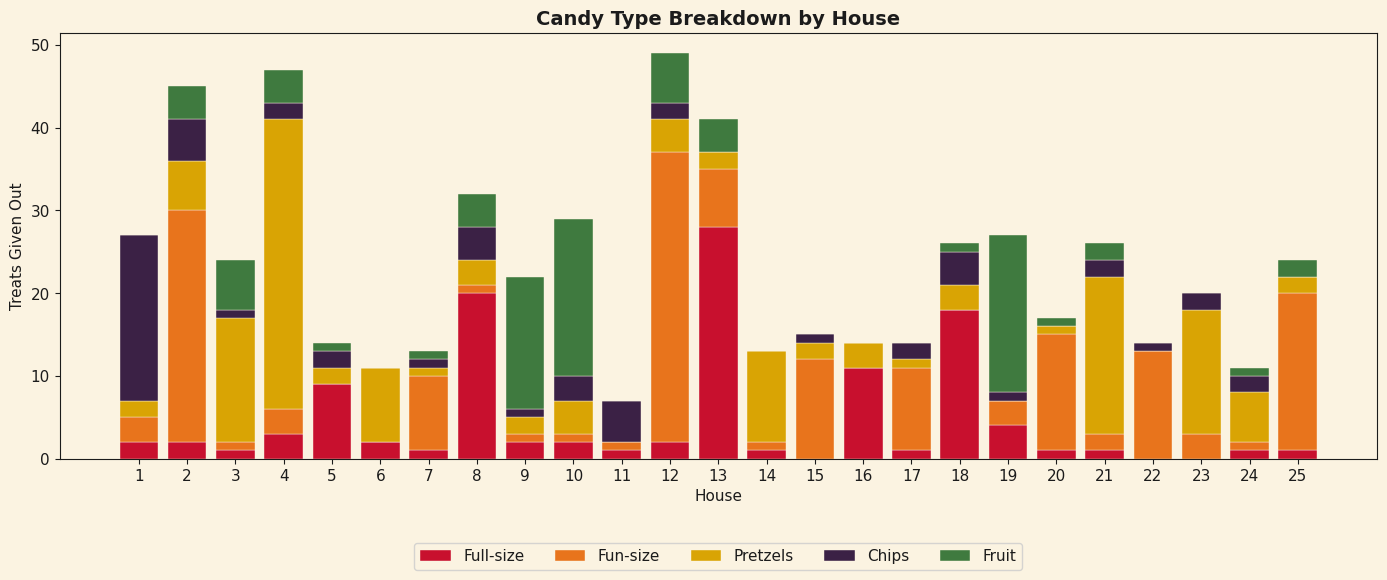

In [5]:
candy_counts = pd.crosstab(arrivals_df["House"], arrivals_df["CandyType"]).reindex(
    index=house_ids, columns=CANDY_TYPES, fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(N_HOUSES)
for candy, color in zip(CANDY_TYPES, CANDY_COLORS):
    ax.bar(candy_counts.index, candy_counts[candy], bottom=bottom,
           color=color, label=candy, edgecolor=PALETTE["cream"], linewidth=0.3)
    bottom += candy_counts[candy].values

ax.set_xticks(house_ids)
ax.set_xlabel("House")
ax.set_ylabel("Treats Given Out")
ax.set_title("Candy Type Breakdown by House")
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.tight_layout()
plt.savefig("02_candy_breakdown.png", dpi=150, facecolor=PALETTE["cream"])
plt.show()

### Save for the next notebooks

In [6]:
houses_df.to_csv("houses.csv", index=False)
arrivals_df.to_csv("arrivals.csv", index=False)